# Análisis Exploratorio de Datos (EDA)
## Modelo de Clasificación Multi-Output

Este notebook realiza un análisis profesional y completo sobre un conjunto de datos para predecir múltiples variables objetivo a partir de características de los usuarios.


In [14]:
!pip install "nbformat>=4.2.0" ipykernel

## 1. Configuración y carga de datos


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap.umap_ as umap
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)

import sys
import os
sys.path.insert(0, os.path.abspath(''))

from src.config import *
from src import eda_utils as eda


In [16]:
dataset_path = 'data/dataset.csv'
try:
    df = pd.read_csv(dataset_path)
    print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas.")
except FileNotFoundError:
    print(f"⚠️ No se encontró dataset en {dataset_path}. Generando dataset sintético para demostración.")
    np.random.seed(42)
    n_samples = 1000
    df = pd.DataFrame({
        'edad': np.random.randint(18, 65, n_samples),
        'hora_lectura_preferida': np.random.choice(['mañana', 'tarde', 'noche', 'madrugada'], n_samples),
        'velocidad_lectura': np.random.choice(['lenta', 'media', 'alta'], n_samples),
        'engagement_promedio': np.random.uniform(0.1, 1.0, n_samples),
        'valence_musical_pref': np.random.uniform(0.0, 1.0, n_samples),
        'energia_musical_pref': np.random.uniform(0.0, 1.0, n_samples),
        'contenido_visual_pref': np.random.choice(['series cortas', 'series largas', 'películas', 'documentales'], n_samples),
        'genero_libro_rec': np.random.choice(['thriller', 'romance', 'ciencia ficción', 'historia'], n_samples),
        'tipo_vino_rec': np.random.choice(['bajo en acidez', 'alta graduación', 'espumoso', 'tinto roble'], n_samples),
        'genero_musical_rec': np.random.choice(['pop', 'rock', 'clásica', 'jazz', 'electrónica'], n_samples),
        'genero_serie_rec': np.random.choice(['drama', 'comedia', 'acción', 'misterio'], n_samples)
    })
    
    os.makedirs('data', exist_ok=True)
    df.to_csv(dataset_path, index=False)
    print("Sintético guardado en data/dataset.csv")

eda.check_dataframe_schema(df)


Dataset cargado: 1000 filas, 11 columnas.
✅ Todas las columnas esperadas están presentes.
✅ Los tipos de datos parecen correctos en base a las columnas requeridas.


True

## 2. Inspección Inicial


In [17]:
display(df.head())
display(df.info())
display(df.describe(include='all').T)


,edad,hora_lectura_preferida,velocidad_lectura,engagement_promedio,valence_musical_pref,energia_musical_pref,contenido_visual_pref,genero_libro_rec,tipo_vino_rec,genero_musical_rec,genero_serie_rec
0,27,manana,alta,0.85,0.51,0.69,series largas,ciencia ficcion,espumoso,electronica,ciencia ficcion
1,18,tarde,media,0.88,0.75,0.55,documentales,fantasia,afrutado,electronica,comedia
2,26,tarde,alta,0.85,0.57,0.65,documentales,fantasia,afrutado,pop,ciencia ficcion
3,32,tarde,media,0.89,0.61,0.54,peliculas,fantasia,dulce,reggaeton,ciencia ficcion
4,21,noche,alta,0.86,0.60,0.74,documentales,ciencia ficcion,seco,electronica,ciencia ficcion


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   edad                    1000 non-null   int64  
 1   hora_lectura_preferida  1000 non-null   str    
 2   velocidad_lectura       1000 non-null   str    
 3   engagement_promedio     1000 non-null   float64
 4   valence_musical_pref    1000 non-null   float64
 5   energia_musical_pref    1000 non-null   float64
 6   contenido_visual_pref   1000 non-null   str    
 7   genero_libro_rec        1000 non-null   str    
 8   tipo_vino_rec           1000 non-null   str    
 9   genero_musical_rec      1000 non-null   str    
 10  genero_serie_rec        1000 non-null   str    
dtypes: float64(3), int64(1), str(7)
memory usage: 136.5 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
edad,1000.0,NaN,NaN,NaN,30.417,9.001007,18.0,24.0,29.0,36.0,65.0
hora_lectura_preferida,1000,3,noche,429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
velocidad_lectura,1000,3,alta,432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engagement_promedio,1000.0,NaN,NaN,NaN,0.76036,0.135487,0.33,0.66,0.76,0.86,1.0
valence_musical_pref,1000.0,NaN,NaN,NaN,0.56262,0.172794,0.0,0.4375,0.55,0.69,1.0
energia_musical_pref,1000.0,NaN,NaN,NaN,0.55853,0.169215,0.06,0.44,0.56,0.69,1.0
contenido_visual_pref,1000,5,series largas,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genero_libro_rec,1000,5,ciencia ficcion,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_vino_rec,1000,5,espumoso,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genero_musical_rec,1000,5,electronica,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Análisis de Valores Faltantes


In [18]:
eda.plot_missing_values(df)


✅ No se encontraron valores faltantes en el dataset.


## 4. Análisis Univariado
### Numéricas


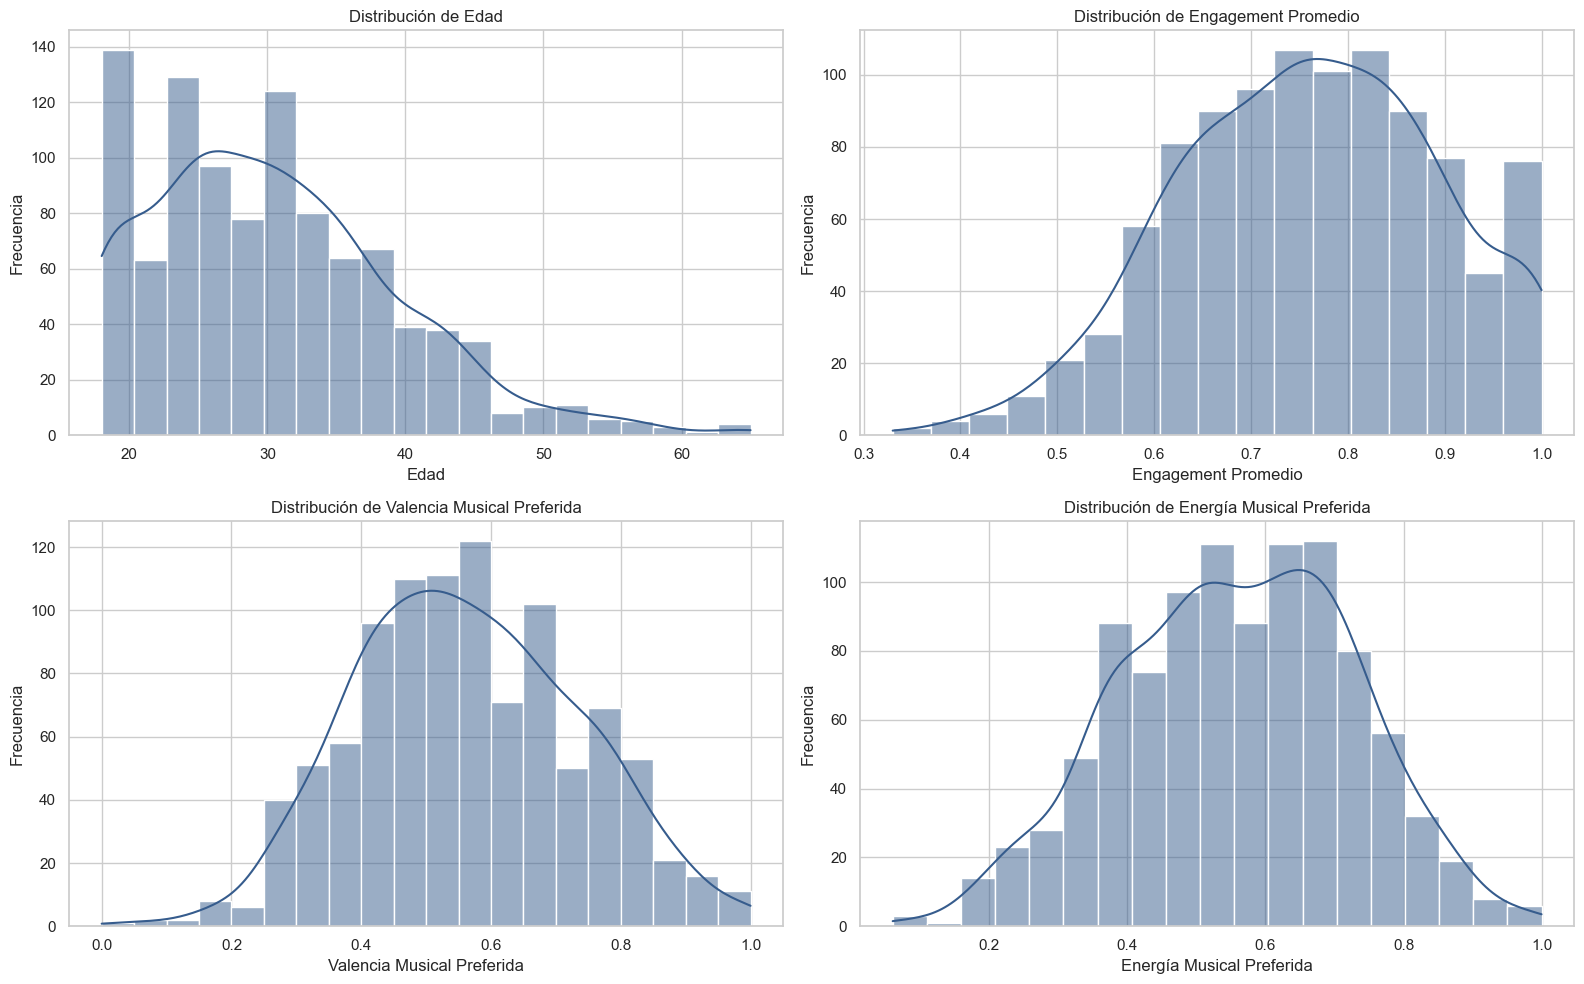

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_FEATURES):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette(PALETTE_MAIN)[1])
    axes[i].set_title(f'Distribución de {display_name(col)}', fontsize=12)
    axes[i].set_xlabel(display_name(col))
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


### Categóricas (Features)


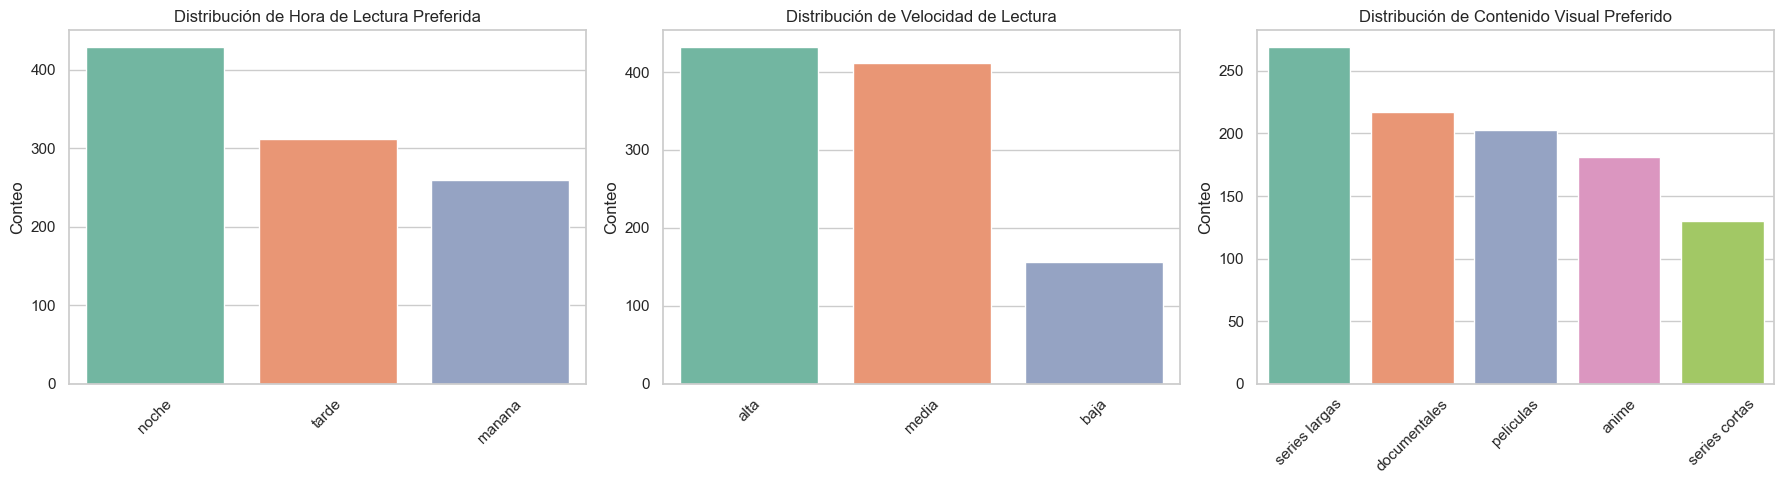

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_FEATURES):
    sns.countplot(data=df, x=col, ax=axes[i], palette=PALETTE_CATEGORICAL, order=df[col].value_counts().index)
    axes[i].set_title(f'Distribución de {display_name(col)}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Conteo')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Targets (Distribución de clases)


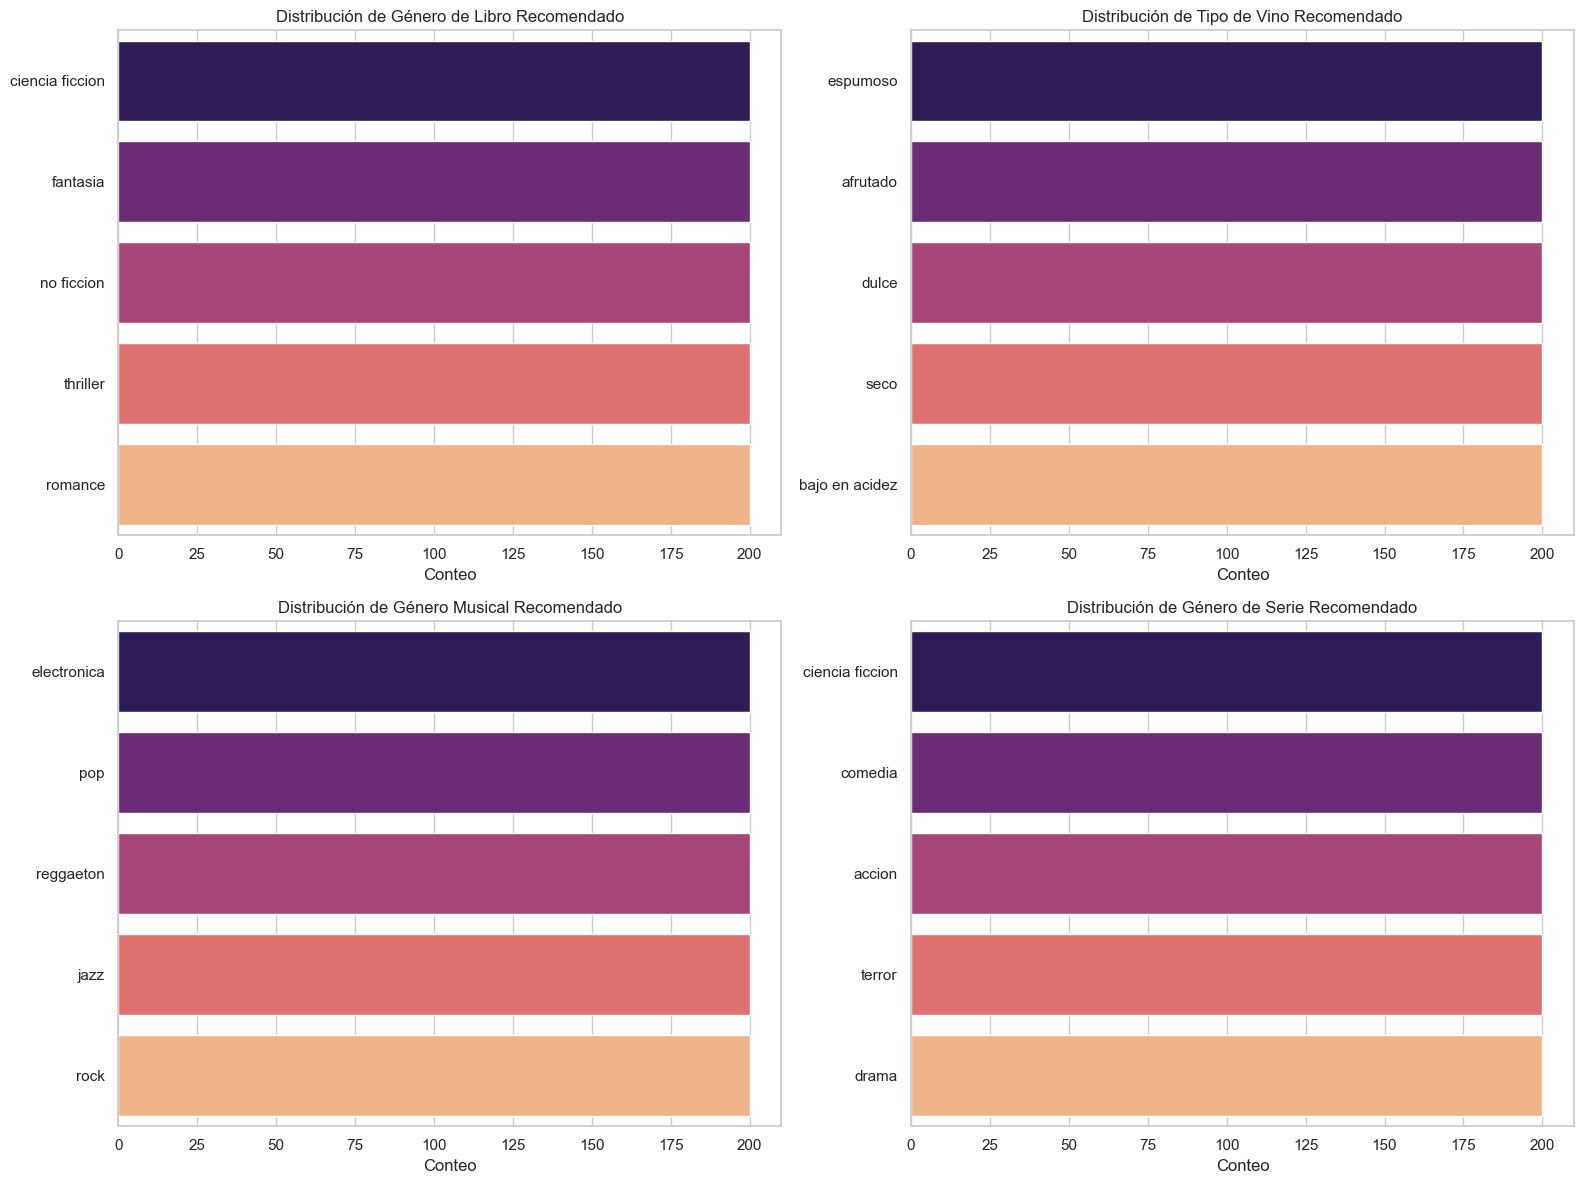

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(TARGET_COLUMNS):
    sns.countplot(data=df, y=col, ax=axes[i], palette='magma', order=df[col].value_counts().index)
    axes[i].set_title(f'Distribución de {display_name(col)}')
    axes[i].set_ylabel('')
    axes[i].set_xlabel('Conteo')

plt.tight_layout()
plt.show()


## 5. Análisis Bivariado (Features vs Targets)


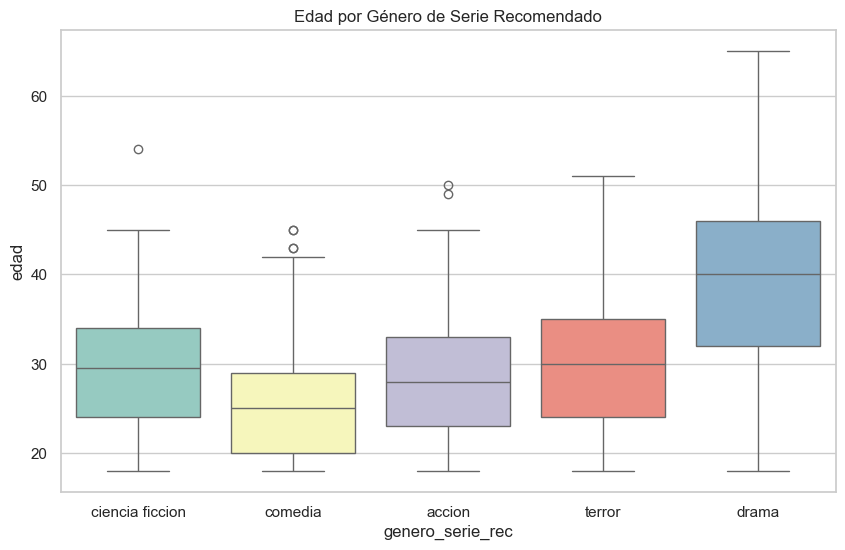

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='genero_serie_rec', y='edad', palette='Set3')
plt.title('Edad por Género de Serie Recomendado')
plt.show()


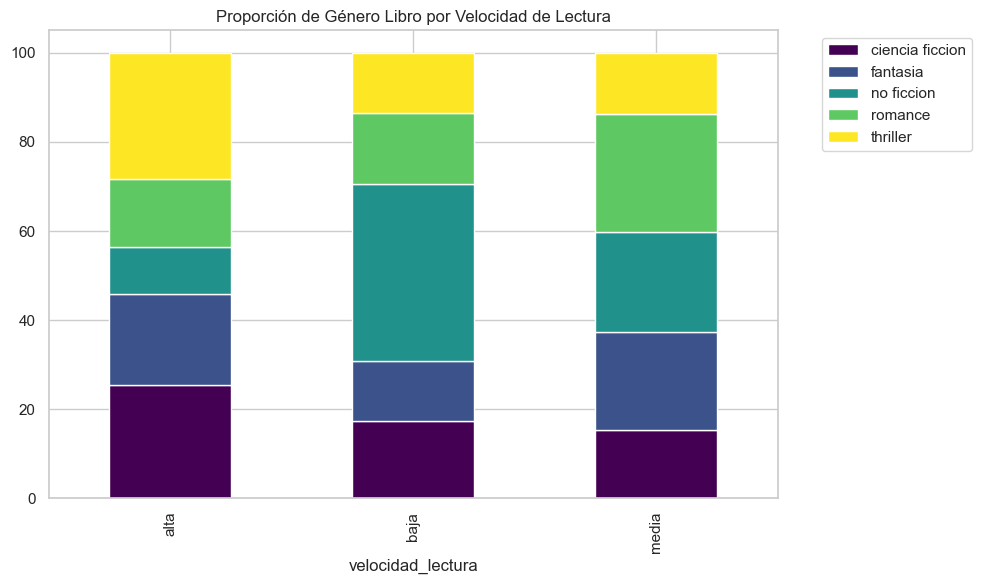

In [23]:
crosstab = pd.crosstab(df['velocidad_lectura'], df['genero_libro_rec'], normalize='index') * 100
crosstab.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title('Proporción de Género Libro por Velocidad de Lectura')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 6. Análisis de Correlación


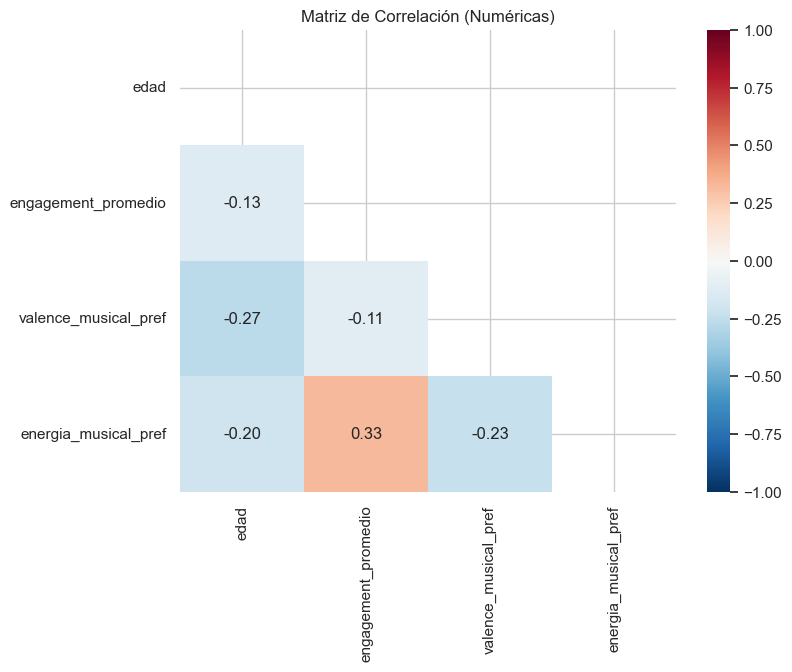

In [24]:
plt.figure(figsize=(8, 6))
corr = df[NUMERICAL_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0, fmt='.2f')
plt.title('Matriz de Correlación (Numéricas)')
plt.show()


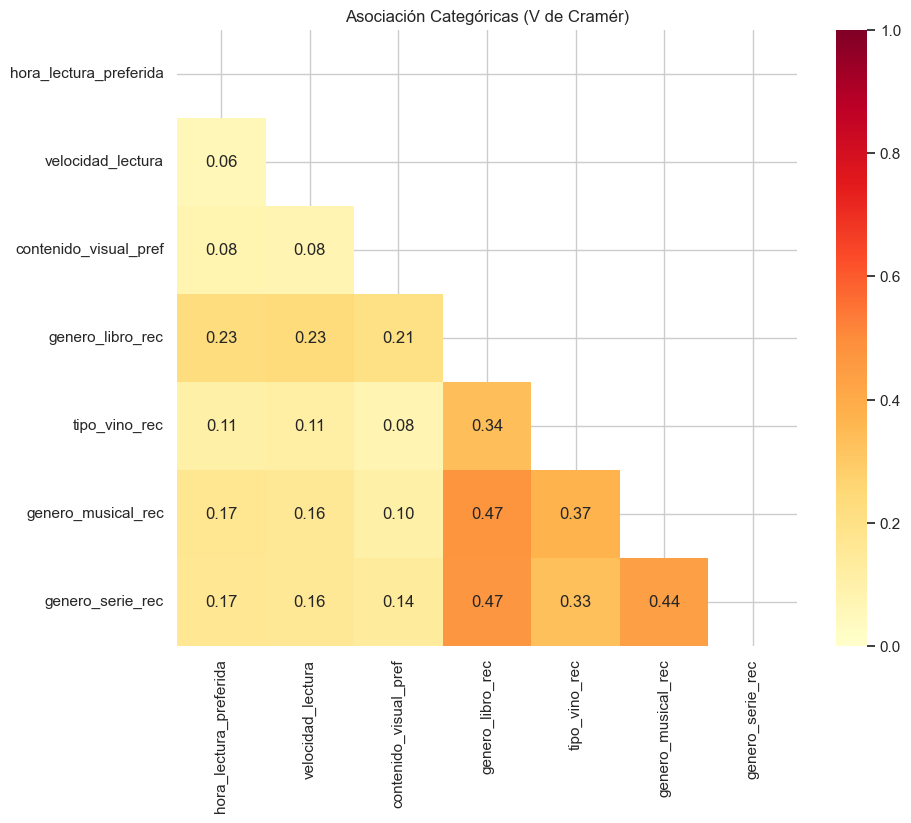

In [25]:
all_cats = CATEGORICAL_FEATURES + TARGET_COLUMNS
cramers_matrix = pd.DataFrame(np.zeros((len(all_cats), len(all_cats))), index=all_cats, columns=all_cats)

for i in range(len(all_cats)):
    for j in range(len(all_cats)):
        cramers_matrix.iloc[i, j] = eda.cramers_v(pd.crosstab(df[all_cats[i]], df[all_cats[j]]))

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(cramers_matrix, dtype=bool))
sns.heatmap(cramers_matrix, mask=mask, annot=True, cmap='YlOrRd', vmin=0, vmax=1, fmt='.2f')
plt.title("Asociación Categóricas (V de Cramér)")
plt.show()


## 7. Análisis de Componentes Principales (PCA)


Varianza explicada: 28.42%


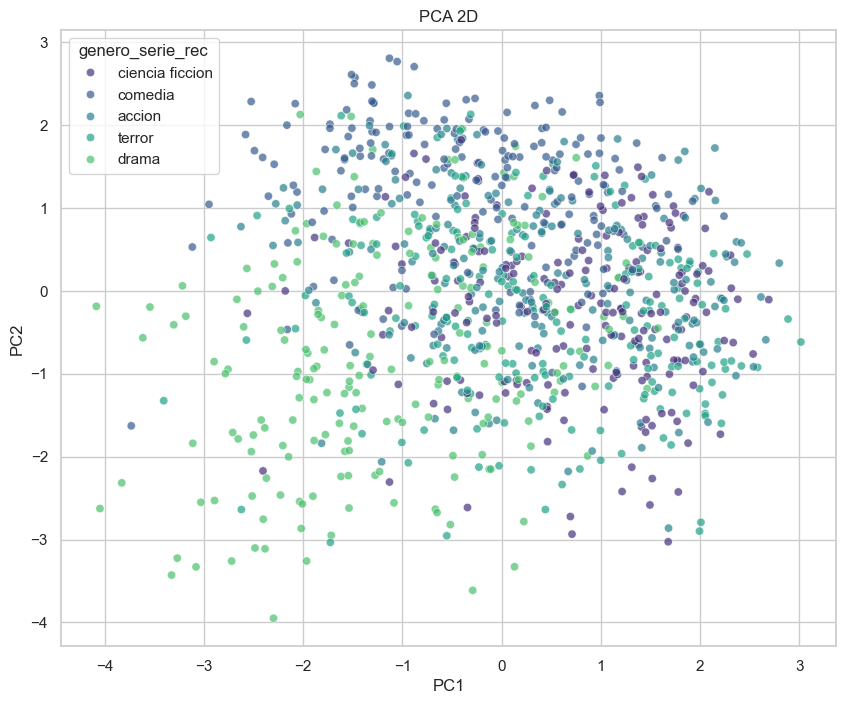

In [26]:
df_encoded = pd.get_dummies(df[ALL_FEATURES], columns=CATEGORICAL_FEATURES, drop_first=True)
X_scaled = StandardScaler().fit_transform(df_encoded)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca = pd.concat([df_pca, df[TARGET_COLUMNS]], axis=1)

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='genero_serie_rec', alpha=0.7)
plt.title('PCA 2D')
plt.show()


## 8. UMAP


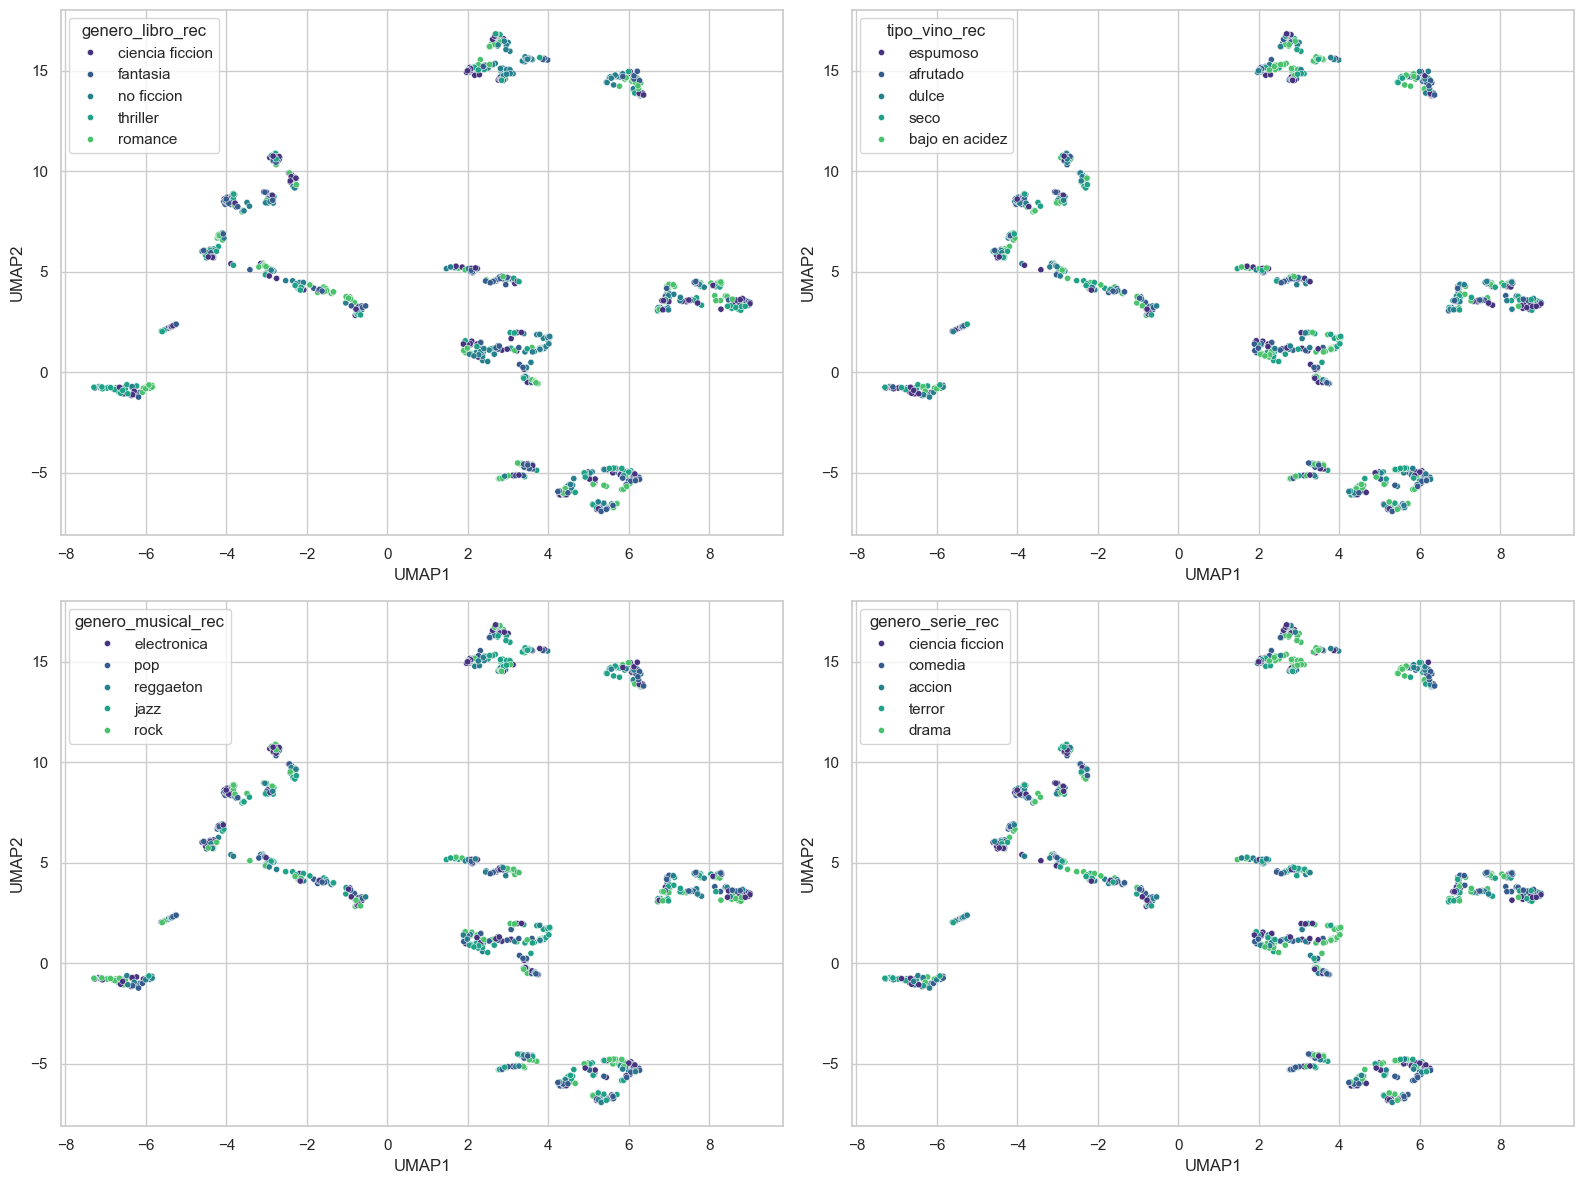

In [27]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X_scaled)

df_umap = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
df_umap = pd.concat([df_umap, df[TARGET_COLUMNS]], axis=1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for i, col in enumerate(TARGET_COLUMNS):
    sns.scatterplot(data=df_umap, x='UMAP1', y='UMAP2', hue=col, ax=axes.flatten()[i], s=20)
plt.tight_layout()
plt.show()


## 9. Análisis Multi-Target


In [28]:
display(df[TARGET_COLUMNS].value_counts().reset_index().head(10))


,genero_libro_rec,tipo_vino_rec,genero_musical_rec,genero_serie_rec,count
0,no ficcion,seco,jazz,drama,62
1,no ficcion,bajo en acidez,jazz,drama,52
2,romance,afrutado,pop,comedia,39
3,romance,dulce,pop,comedia,28
4,thriller,seco,rock,terror,22
5,thriller,espumoso,rock,terror,21
6,ciencia ficcion,espumoso,rock,ciencia ficcion,19
7,thriller,espumoso,rock,accion,19
8,fantasia,afrutado,pop,comedia,18
9,thriller,espumoso,rock,ciencia ficcion,15


## 10. Conclusiones y Recomendaciones
* **Features clave:** Evaluar importancia.
* **Modelado:** Utilizar MultiOutputClassifier.
